# 02 — Chunking Experiments

Compare chunking strategies and measure their effect on retrieval quality.

In [1]:
import sys, json
sys.path.insert(0, '..')
from pathlib import Path
from app.config import CLEANED_DOCS_DIR
from app.processing.chunker import DocumentChunker

# Load a sample cleaned document
sample_files = list(CLEANED_DOCS_DIR.rglob('*.json'))[:1]
if not sample_files:
    print('Run scripts/build_corpus.py first.')
else:
    doc = json.loads(sample_files[0].read_text())
    print(f'Loaded: {doc["ticker"]} {doc["section_name"]} ({len(doc["text"])} chars)')

Loaded: AAPL Preamble (18063 chars)


In [2]:
# Compare chunk sizes
import pandas as pd

results = []
for chunk_size, overlap in [(400, 80), (800, 150), (1200, 200)]:
    chunker = DocumentChunker(chunk_size=chunk_size, chunk_overlap=overlap)
    chunks = chunker.chunk_document(doc)
    avg_len = sum(len(c['text']) for c in chunks) / len(chunks)
    results.append({'chunk_size': chunk_size, 'overlap': overlap,
                    'num_chunks': len(chunks), 'avg_chars': round(avg_len)})

pd.DataFrame(results)

,chunk_size,overlap,num_chunks,avg_chars
0,400,80,60,329
1,800,150,30,683
2,1200,200,21,961


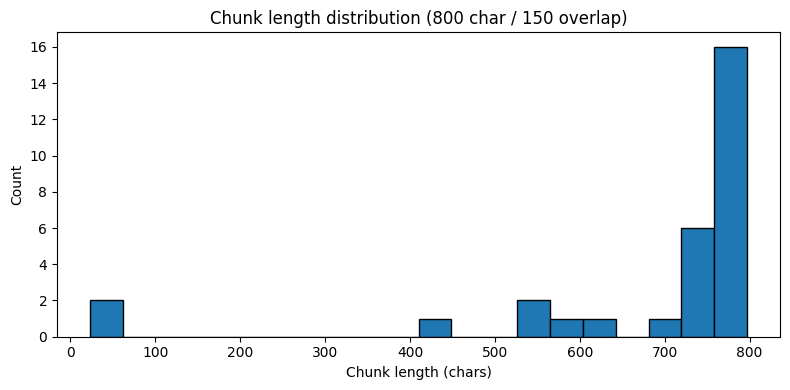

In [4]:
# Visualise chunk length distribution for selected strategy
import matplotlib.pyplot as plt

chunker = DocumentChunker(chunk_size=800, chunk_overlap=150)
chunks = chunker.chunk_document(doc)
lengths = [len(c['text']) for c in chunks]

plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=20, edgecolor='black')
plt.xlabel('Chunk length (chars)')
plt.ylabel('Count')
plt.title('Chunk length distribution (800 char / 150 overlap)')
plt.tight_layout()
plt.show()